# Temperature handling check

Biodiesel trajectories are isothermal, so temperature is constant within a trajectory. Hydrogen
Stage 1 integrates only the species but still feeds temperature into the kinetic core, and that
temperature comes from the stored training data. The adaptive ODE solver evaluates the RHS at
times between the stored observations, so temperature has to be supplied there too. This notebook
checks how that currently works and how the interpolated temperature compares to a dense Cantera
run.

In [1]:
%matplotlib inline
import sys, inspect, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "chemkan" / "__init__.py").exists():
        CH = base; break                        # CH: repo's chemkan/ package root
for p in (CH / "src", CH / "scripts", CH / "scripts" / "data_gen"):
    sys.path.insert(0, str(p))

from _data import load_hydrogen, load_biodiesel, load_input_scaling
from chemkan.temperature import ObservedTemperature, ConstantTemperature
from chemkan.dynamics import KineticDynamics, ChemKANDynamics
from chemkan.model import ChemKAN
from chemkan.solver import SolverConfig, integrate

## Biodiesel

In [2]:
import train_biodiesel
for ln in inspect.getsource(train_biodiesel.main).splitlines():
    if "Temperature(" in ln:
        print(ln.strip())

bd = load_biodiesel("train")                # bd: biodiesel training split (dict of tensors)
T0 = float(bd["T_const"][0])                # T0: the single isothermal reactor temperature [K]
print("T:", round(T0, 2), "K")
print("T min:", round(T0, 2), "K")
print("T max:", round(T0, 2), "K")
print("T range:", 0.0, "K")

prov = ConstantTemperature(bd["T_const"][0:1])   # prov: the actual constant-T provider used
tb = bd["t"].numpy()                        # tb: biodiesel time grid [s]
for tt in [tb[0], tb[len(tb)//3], tb[-1]]:
    print(f"provider(t={tt:.1f}) = {float(prov(torch.tensor(tt))[0,0]):.2f} K")

dynamics = KineticDynamics(core, ConstantTemperature(T_const),
T: 334.43 K
T min: 334.43 K
T max: 334.43 K
T range: 0.0 K
provider(t=0.0) = 334.43 K
provider(t=10.3) = 334.43 K
provider(t=30.0) = 334.43 K


## Hydrogen data

In [3]:
hy = load_hydrogen("train")                 # hy: hydrogen training split (dict of tensors)
full = hy["full_TBm1"].numpy()              # full: (time, trajectory, m+1) = [Y_1..Y_m, T]
t_hy = hy["t"].numpy()                       # t_hy: 50 stored sample times [s]
m = hy["species_TBm"].shape[-1]             # m: number of species (temperature sits at column m)
T_all = full[:, :, m]                       # T_all: (time, trajectory) temperature slice
npz = np.load(CH / "data" / "generated" / "hydrogen.npz", allow_pickle=True)
train_ics = npz["train_ics"]                # train_ics: (trajectory, 2) = [T0, phi] per case
pressure = float(npz["pressure"])           # pressure: reactor pressure [Pa] (1 atm)

print("full_TBm1 shape:", full.shape)
print("trajectories:", T_all.shape[1])
print("stored time points:", len(t_hy))
print(f"T min:  {T_all.min():.1f} K")
print(f"T mean: {T_all.mean():.1f} K")
print(f"T max:  {T_all.max():.1f} K")
print(f"T range:{T_all.max() - T_all.min():.1f} K")

adj = np.abs(np.diff(T_all, axis=0))        # adj: |T jump| between adjacent stored points
ti, bj = np.unravel_index(adj.argmax(), adj.shape)   # ti/bj: time-index & trajectory of largest jump
print()
print("largest adjacent jump:", f"{adj[ti, bj]:.1f} K")
print("trajectory index:", bj)
print(f"T0: {train_ics[bj,0]:.0f} K, phi: {train_ics[bj,1]:.2f}")
print(f"neighbors: {T_all[ti,bj]:.1f} K -> {T_all[ti+1,bj]:.1f} K")
print(f"times: {t_hy[ti]:.3e} s -> {t_hy[ti+1]:.3e} s")

full_TBm1 shape: (50, 35, 10)
trajectories: 35
stored time points: 50
T min:  950.0 K
T mean: 1961.0 K
T max:  2781.1 K
T range:1831.1 K

largest adjacent jump: 635.8 K
trajectory index: 22
T0: 1100 K, phi: 1.30
neighbors: 1193.2 K -> 1829.0 K
times: 8.571e-05 s -> 9.796e-05 s


## Temperature interpolation vs dense Cantera

Pick the trajectory with the largest interpolation error, then compare the stored points, the
`ObservedTemperature` interpolation, and a matched dense Cantera run.

In [4]:
from reactor import integrate_case as ct_integrate, species_index
import generate_hydrogen as genh
_, keep = species_index(genh.MECH, genh.DROP)   # keep: indices of the species we retain

def observed_interp(times, temps, query):
    # Use the same ObservedTemperature provider the model calls in Stage 1.
    # Its forward takes one scalar solver time, so evaluate element-wise.
    prov = ObservedTemperature(torch.as_tensor(times), torch.as_tensor(temps).reshape(-1, 1, 1))
    return np.array([float(prov(torch.tensor(x, dtype=torch.float64))[0, 0]) for x in query])

t_dense = np.linspace(t_hy[0], t_hy[-1], 2000)   # t_dense: fine grid for smooth reference/plots
dense_T = {}                                # dense_T: {trajectory -> dense Cantera temperature}
maxerr = np.zeros(T_all.shape[1])           # maxerr: per-trajectory max linear-interp error [K]
rise = np.zeros(T_all.shape[1])             # rise: per-trajectory total temperature rise [K]
for b in range(T_all.shape[1]):
    # t_dense (2000 pts) is only the OUTPUT sampling grid, not Cantera's steps.
    # net.advance() integrates the stiff ODE with its own adaptive internal steps
    # (accuracy is set by rtol/atol, not by this grid); the dense grid just samples
    # that already-accurate solution finely between the 50 stored points so the
    # reference curve is smooth. [:, -1] keeps temperature only.
    dref = ct_integrate(genh.MECH, genh.FUEL, genh.OXIDIZER,
                        float(train_ics[b, 0]), float(train_ics[b, 1]),
                        t_dense, pressure, keep)[:, -1]
    dense_T[b] = dref
    maxerr[b] = np.abs(observed_interp(t_hy, T_all[:, b], t_dense) - dref).max()
    rise[b] = T_all[:, b].max() - T_all[:, b].min()

worst = int(maxerr.argmax())                # worst: trajectory with the largest interp error
print("worst trajectory:", worst)
print(f"T0: {train_ics[worst,0]:.0f} K")
print(f"phi: {train_ics[worst,1]:.2f}")
print(f"max interpolation error: {maxerr[worst]:.1f} K")

worst trajectory: 33
T0: 1200 K
phi: 1.30
max interpolation error: 167.5 K


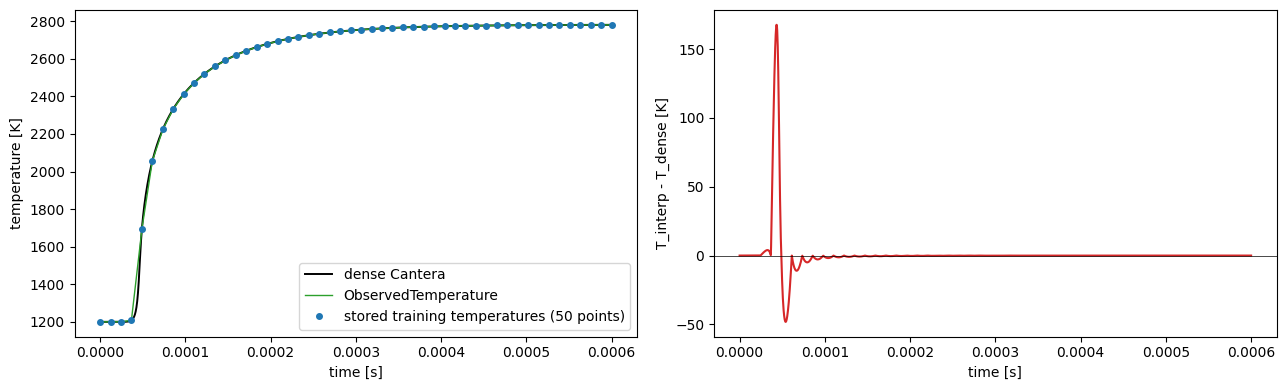

MAE: 3.1 K
RMSE: 16.8 K
max abs error: 167.5 K
time of max error: 4.352e-05 s
steep-rise window: [2.449e-05, 6.122e-05] s
max error inside window: 167.5 K
max error outside window: 11.0 K


In [5]:
b = worst                                    # b: the trajectory we zoom in on
Tsp = T_all[:, b]                            # Tsp: 50 stored temperatures for this trajectory
Tref = dense_T[b]                            # Tref: dense Cantera temperature (reference)
otemp = ObservedTemperature(torch.as_tensor(t_hy), torch.as_tensor(Tsp).reshape(-1, 1, 1))
Tint = np.array([float(otemp(torch.tensor(x, dtype=torch.float64))[0, 0]) for x in t_dense])
err = Tint - Tref                            # err: ObservedTemperature minus reference [K]
kmax = int(np.abs(err).argmax())             # kmax: index (into t_dense) of the peak error

i_steep = int(np.diff(Tsp).argmax())                      # i_steep: index of steepest jump on t_hy grid
lo_t = t_hy[max(0, i_steep - 1)]                          # lo_t/hi_t: autoignition window in real time
hi_t = t_hy[min(len(t_hy) - 1, i_steep + 2)]
win = (t_dense >= lo_t) & (t_dense <= hi_t)               # win: mask selecting the ignition window

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(t_dense, Tref, "k-", lw=1.4, label="dense Cantera")
ax[0].plot(t_dense, Tint, color="tab:green", lw=1.0, label="ObservedTemperature")
ax[0].plot(t_hy, Tsp, "o", color="tab:blue", ms=4, label="stored training temperatures (50 points)")
ax[0].set_xlabel("time [s]"); ax[0].set_ylabel("temperature [K]"); ax[0].legend()
ax[1].plot(t_dense, err, color="tab:red"); ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_xlabel("time [s]"); ax[1].set_ylabel("T_interp - T_dense [K]")
plt.tight_layout(); plt.show()

print(f"MAE: {np.abs(err).mean():.1f} K")
print(f"RMSE: {np.sqrt((err**2).mean()):.1f} K")
print(f"max abs error: {np.abs(err).max():.1f} K")
print(f"time of max error: {t_dense[kmax]:.3e} s")
print(f"steep-rise window: [{lo_t:.3e}, {hi_t:.3e}] s")
print(f"max error inside window: {np.abs(err[win]).max():.1f} K")
print(f"max error outside window: {np.abs(err[~win]).max():.1f} K")

### Observation: Interpolation error during autoignition

The largest linear-interpolation error occurs during the rapid autoignition temperature rise. The
stored training temperatures are relatively sparse in this region, so the interpolated curve has to
estimate the temperature between observations. The dense Cantera trajectory is included only as a
high-resolution reference.

## Where Stage-1 temperature is used

```
odeint
  -> KineticDynamics.forward(t, Y)
  -> temperature provider
  -> [Y, T]
  -> kinetic model
  -> dY/dt
```

In [6]:
print(inspect.getsource(KineticDynamics.forward))

    def forward(self, t: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:  # (B, m)->(B, m)
        T = self.temperature(t)                              # (B, 1) physical Kelvin
        u_physical = torch.cat([Y, T], dim=-1)               # (B, m+1) physical
        u_model = (u_physical if self.input_normalizer is None
                   else self.input_normalizer.normalize(u_physical))
        return self.kinetic(u_model)                         # physical dY/dt (B, m)



## Actual ODE solver call times

In [7]:
def find(name):
    for p in (CH / name, CH.parent / name, Path.cwd() / name):
        if p.exists():
            return p

# 1- Load checkpoint (the trained model).
ck = torch.load(find("hydrogen_chemkan.pt"), map_location="cpu", weights_only=False)  # ck: checkpoint
a = ck["architecture"]                       # a: saved architecture hyper-parameters

# 2- Rebuild the ChemKAN architecture from the saved hyper-parameters.
fm = ChemKAN(species_dim=m, hidden_dim=a["hidden_dim"], num_basis=a["num_basis"],
             n_mu=a["n_mu"], use_base_act=a["use_base_act"])                          # fm: full model

# 3- Load the trained weights into that architecture.
fm.load_state_dict(ck["model_state"])
innorm = load_input_scaling(ck, torch.device("cpu"))   # innorm: pre-KAN input normalizer

dyn = KineticDynamics(fm.kinetic, otemp, input_normalizer=innorm)   # dyn: the Stage-1 RHS
rhs_times = []                               # rhs_times: every time the solver evaluates the RHS
# A forward pre-hook records t on each RHS call; it does not change the dynamics.
dyn.register_forward_pre_hook(lambda mod, args: rhs_times.append(float(args[0].detach())))
cfg = SolverConfig("tsit5", 1e-6, 1e-8, "direct_autograd")   # cfg: solver method + tolerances
Y0 = torch.as_tensor(full[0, worst, :m], dtype=torch.get_default_dtype()).reshape(1, m)   # Y0: initial species
_ = integrate(dyn, Y0, torch.as_tensor(t_hy, dtype=torch.get_default_dtype()), cfg)

internal = np.array(rhs_times)               # internal: every RHS time the solver requested
between = internal[(internal > t_hy[0]) & (internal < t_hy[-1])]
between = between[~np.isclose(between[:, None], t_hy[None, :], rtol=1e-9, atol=1e-12).any(1)]   # between: internal times strictly off the stored grid
print("stored/output times:", len(t_hy))
print("RHS evaluations:", len(internal))
print("RHS evaluations strictly between stored times:", between.size)

ts = float(between[np.argmin(np.abs(between - t_dense[kmax]))])   # ts: internal time nearest peak error
k = int(np.clip(np.searchsorted(t_hy, ts), 1, len(t_hy) - 1))    # k: right-bracket stored index for ts
print()
print(f"t_lower:    {t_hy[k-1]:.6e} s")
print(f"t_internal: {ts:.6e} s")
print(f"t_upper:    {t_hy[k]:.6e} s")
print(f"T_lower:    {Tsp[k-1]:.1f} K")
print(f"T_upper:    {Tsp[k]:.1f} K")
# Exact Cantera at this RHS time (start at 0, advance to ts) rather than
# interpolating the dense reference again.
Tc_exact = float(ct_integrate(genh.MECH, genh.FUEL, genh.OXIDIZER,
                              float(train_ics[worst, 0]), float(train_ics[worst, 1]),
                              np.array([0.0, ts]), pressure, keep)[-1, -1])
Tobs = float(otemp(torch.tensor(ts))[0, 0])
print(f"T_interpolated:  {Tobs:.1f} K")
print(f"T_cantera_exact: {Tc_exact:.1f} K")
print(f"difference:      {Tobs - Tc_exact:+.1f} K")

stored/output times: 50
RHS evaluations: 302
RHS evaluations strictly between stored times: 295

t_lower:    3.673469e-05 s
t_internal: 4.358374e-05 s
t_upper:    4.897959e-05 s
T_lower:    1208.5 K
T_upper:    1692.8 K
T_interpolated:  1479.4 K
T_cantera_exact: 1312.0 K
difference:      +167.4 K


We rebuilt the trained model and selected the hydrogen training condition with the largest linear-interpolation error ($T_0$=1200 K, $\Phi$=1.3). A forward hook recorded every time Tsit5 evaluated the KineticDynamics right-hand side during one complete single-trajectory Stage-1 integration. The solver made 302 RHS evaluations, of which 295 occurred between the 50 stored observation times and therefore required an interpolated temperature. At an actual recorded RHS time near the peak interpolation error, ObservedTemperature was also compared directly against the Cantera reference.

## Linear-interpolation error across all 35 hydrogen training trajectories

min:    0.0 K
median: 86.6 K
mean:   80.6 K
max:    167.5 K
max at trajectory 33: T0=1200 K, phi=1.30
corr(rise, max error): 0.79


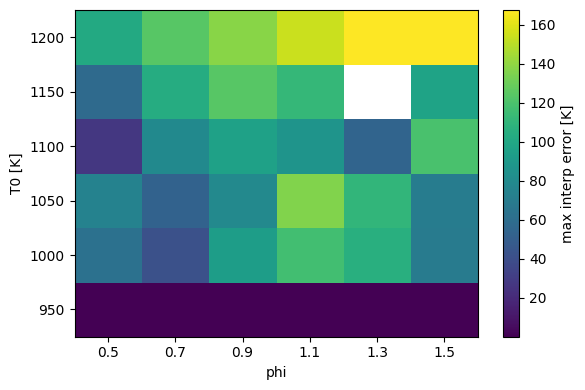

In [8]:
print(f"min:    {maxerr.min():.1f} K")
print(f"median: {np.median(maxerr):.1f} K")
print(f"mean:   {maxerr.mean():.1f} K")
print(f"max:    {maxerr.max():.1f} K")
w = int(maxerr.argmax())                     # w: worst trajectory (same as `worst` above)
print(f"max at trajectory {w}: T0={train_ics[w,0]:.0f} K, phi={train_ics[w,1]:.2f}")
print(f"corr(rise, max error): {np.corrcoef(rise, maxerr)[0,1]:.2f}")

T0s = sorted({float(v) for v in train_ics[:, 0]})   # T0s: distinct initial temperatures [K]
phis = sorted({float(v) for v in train_ics[:, 1]})  # phis: distinct equivalence ratios
G = np.full((len(T0s), len(phis)), np.nan)          # G: max interp error on the (T0, phi) grid
for b in range(len(maxerr)):
    G[T0s.index(float(train_ics[b, 0])), phis.index(float(train_ics[b, 1]))] = maxerr[b]
plt.figure(figsize=(6, 4))
plt.imshow(G, origin="lower", aspect="auto", cmap="viridis")
plt.colorbar(label="max interp error [K]")
plt.xticks(range(len(phis)), [f"{p:.1f}" for p in phis])
plt.yticks(range(len(T0s)), [f"{t:.0f}" for t in T0s])
plt.xlabel("phi"); plt.ylabel("T0 [K]"); plt.tight_layout(); plt.show()

## Stage 2 implementation check

```
[Y, T]
  -> ChemKANDynamics
  -> ChemKAN
  -> [dY/dt, dT/dt]
  -> odeint
```

In [9]:
print(inspect.getsource(ChemKANDynamics.forward))

d = ChemKANDynamics(ChemKAN(species_dim=m, hidden_dim=3, num_basis=5, n_mu=3, use_base_act=False),
                    input_normalizer=None)   # d: a throwaway Stage-2 dynamics, only to inspect structure
print("submodules:", list(dict(d.named_children()).keys()))
has_temp = any("Temperature" in type(c).__name__ for c in d.modules())   # has_temp: explicit confirmation that no T provider is inside (expected False)
print("temperature provider referenced in Stage-2 path:", has_temp)

    def forward(self, t: torch.Tensor, u_physical: torch.Tensor) -> torch.Tensor:
        # (B, m+1) physical -> (B, m+1) physical derivative
        u_model = (u_physical if self.input_normalizer is None
                   else self.input_normalizer.normalize(u_physical))
        return self.model(u_model)

submodules: ['model']
temperature provider referenced in Stage-2 path: False


## 9. Alternatives to linear interpolation

The current implementation uses piecewise-linear interpolation to provide Stage-1 temperature at
ODE-solver internal times. Here I compare three alternative interpolation methods using exactly the
same stored temperature observations. Dense Cantera remains only a reference and is not used as
input to the interpolators.

### 9.1 Construct alternative interpolators

In [10]:
from scipy.interpolate import PchipInterpolator, CubicSpline, Akima1DInterpolator

# All methods are built from exactly the same 50 stored temperatures for the
# worst trajectory; dense Cantera is never used to construct them.
lin = ObservedTemperature(torch.as_tensor(t_hy), torch.as_tensor(Tsp).reshape(-1, 1, 1))   # lin: current provider
pchip = PchipInterpolator(t_hy, Tsp)          # pchip: shape-preserving, no overshoot by design
cubic = CubicSpline(t_hy, Tsp)                 # cubic: default not-a-knot cubic spline
makima = Akima1DInterpolator(t_hy, Tsp, method="makima")   # makima: modified-Akima, less ringing

def lin_eval(x):
    # ObservedTemperature takes one scalar solver time, so evaluate element-wise
    # to mirror how it is actually called during Stage 1.
    return np.array([float(lin(torch.tensor(v, dtype=torch.float64))[0, 0])
                     for v in np.atleast_1d(x)])

print("built from", len(t_hy), "stored temperatures (trajectory", worst, ")")

built from 50 stored temperatures (trajectory 33 )


### 9.2 Plot the alternatives

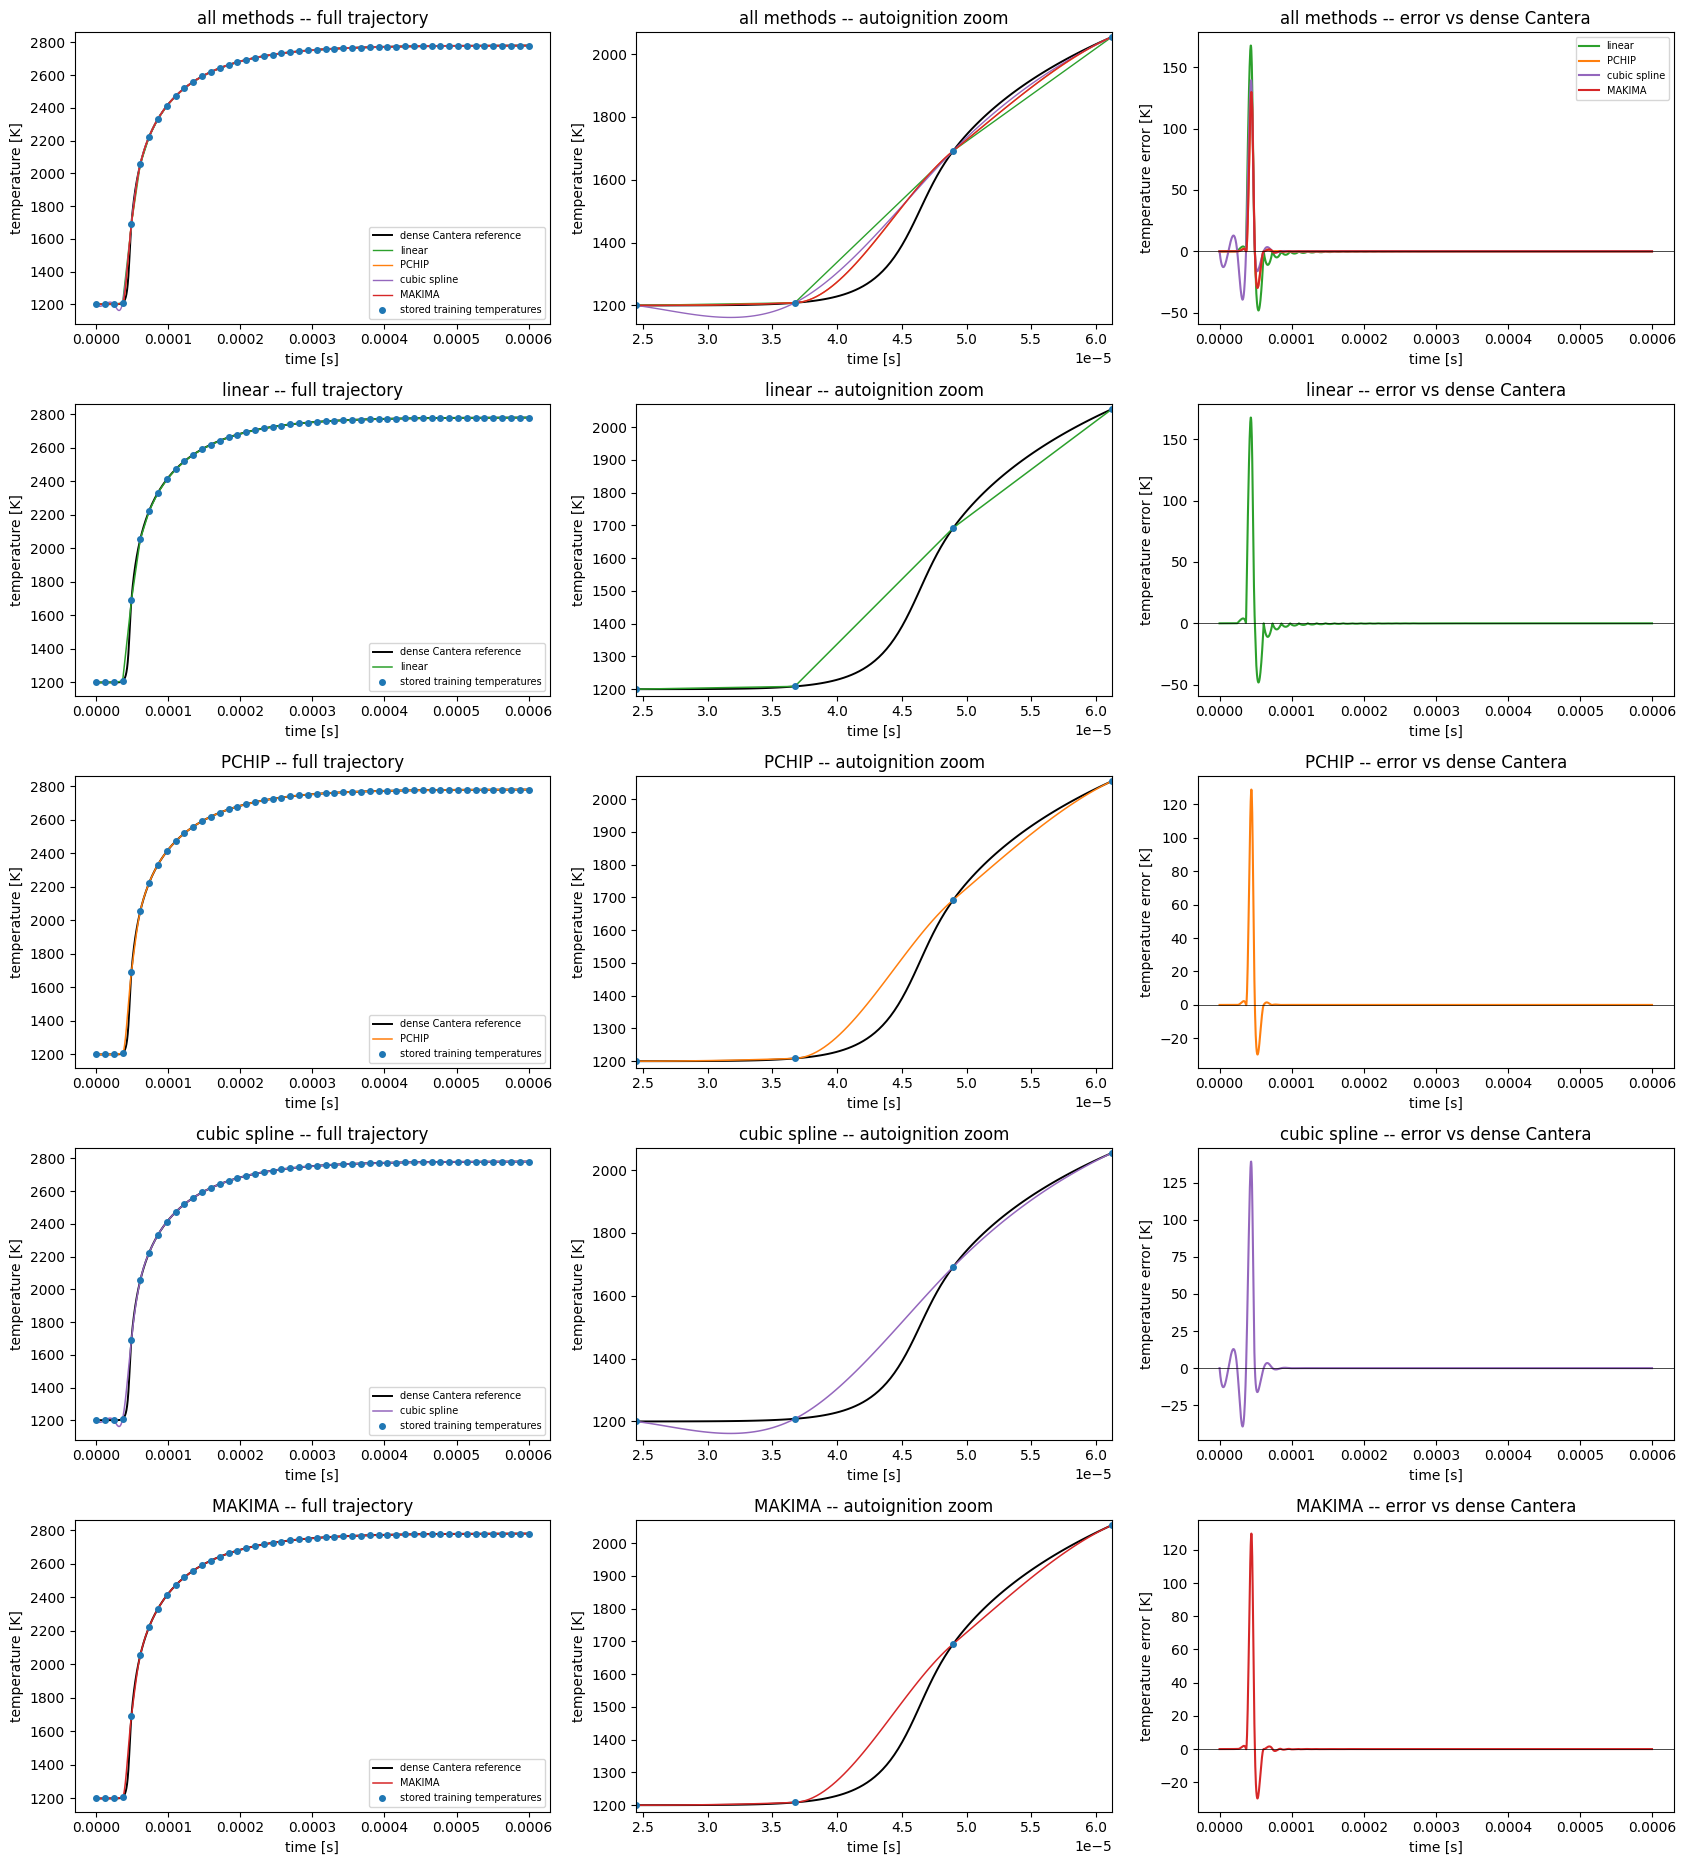

In [11]:
Tl = lin_eval(t_dense)                       # Tl/Tp/Tc/Tm: each method sampled on t_dense
Tp = pchip(t_dense)
Tc = cubic(t_dense)
Tm = makima(t_dense)
curves = [("linear", "tab:green", Tl), ("PCHIP", "tab:orange", Tp),
          ("cubic spline", "tab:purple", Tc), ("MAKIMA", "tab:red", Tm)]   # curves: (name, color, values)

zm = (t_dense >= lo_t) & (t_dense <= hi_t)       # zm: autoignition zoom mask on t_dense
def zoom_ylim(*arrs):                            # y-limits follow the zoom window
    return min(a[zm].min() for a in arrs) - 20, max(a[zm].max() for a in arrs) + 20

# Row 0 overlays every method; rows 1-N show each interpolation on its own
# against dense Cantera so the behaviour between stored points is easy to read.
fig, ax = plt.subplots(1 + len(curves), 3, figsize=(17, 3.75 * (1 + len(curves))))

for a in ax[0, :2]:
    a.plot(t_dense, Tref, "k-", lw=1.4, label="dense Cantera reference")
    for name, col, T in curves:
        a.plot(t_dense, T, color=col, lw=1.0, label=name)
    a.plot(t_hy, Tsp, "o", color="tab:blue", ms=4, label="stored training temperatures")
    a.set_xlabel("time [s]"); a.set_ylabel("temperature [K]")
ax[0, 0].legend(fontsize=7); ax[0, 0].set_title("all methods -- full trajectory")
ax[0, 1].set_xlim(lo_t, hi_t); ax[0, 1].set_ylim(*zoom_ylim(Tref, Tl, Tp, Tc, Tm))
ax[0, 1].set_title("all methods -- autoignition zoom")
for name, col, T in curves:
    ax[0, 2].plot(t_dense, T - Tref, color=col, label=name)
ax[0, 2].axhline(0, color="k", lw=0.5); ax[0, 2].legend(fontsize=7)
ax[0, 2].set_xlabel("time [s]"); ax[0, 2].set_ylabel("temperature error [K]")
ax[0, 2].set_title("all methods -- error vs dense Cantera")

for r, (name, col, T) in enumerate(curves, start=1):
    for a in ax[r, :2]:
        a.plot(t_dense, Tref, "k-", lw=1.4, label="dense Cantera reference")
        a.plot(t_dense, T, color=col, lw=1.1, label=name)
        a.plot(t_hy, Tsp, "o", color="tab:blue", ms=4, label="stored training temperatures")
        a.set_xlabel("time [s]"); a.set_ylabel("temperature [K]")
    ax[r, 0].legend(fontsize=7); ax[r, 0].set_title(f"{name} -- full trajectory")
    ax[r, 1].set_xlim(lo_t, hi_t); ax[r, 1].set_ylim(*zoom_ylim(Tref, T))
    ax[r, 1].set_title(f"{name} -- autoignition zoom")
    ax[r, 2].plot(t_dense, T - Tref, color=col); ax[r, 2].axhline(0, color="k", lw=0.5)
    ax[r, 2].set_xlabel("time [s]"); ax[r, 2].set_ylabel("temperature error [K]")
    ax[r, 2].set_title(f"{name} -- error vs dense Cantera")

plt.tight_layout(); plt.show()

### 9.3 Compare interpolation methods on the linear-worst trajectory

In [12]:
import pandas as pd
methods = {"linear": Tl, "PCHIP": Tp, "cubic spline": Tc, "MAKIMA": Tm}   # methods: name -> dense values
rows = []
for name, Tmeth in methods.items():
    e = Tmeth - Tref; ae = np.abs(e)         # e/ae: signed and absolute error vs reference [K]
    rows.append({
        "Method": name,
        "MAE [K]": round(float(ae.mean()), 2),
        "RMSE [K]": round(float(np.sqrt((e ** 2).mean())), 2),
        "Max abs [K]": round(float(ae.max()), 2),
        "Time of max [s]": f"{t_dense[int(ae.argmax())]:.3e}",
        "Max ignition [K]": round(float(ae[win].max()), 2),
        "Max outside [K]": round(float(ae[~win].max()), 2),
    })
metrics = pd.DataFrame(rows)
metrics

,Method,MAE [K],RMSE [K],Max abs [K],Time of max [s],Max ignition [K],Max outside [K]
0,linear,3.07,16.81,167.54,4.352e-05,167.54,11.03
1,PCHIP,1.70,11.54,128.82,4.412e-05,128.82,1.51
2,cubic spline,2.66,13.59,139.27,4.382e-05,139.27,12.87
3,MAKIMA,1.72,11.63,129.77,4.412e-05,129.77,1.58


In [31]:
from scipy.interpolate import PchipInterpolator, CubicSpline, Akima1DInterpolator

method_names = ["Linear", "PCHIP", "CubicSpline", "MAKIMA"]
# all_me: {method -> (35,)} max absolute interpolation error per trajectory
all_me = {name: np.zeros(T_all.shape[1]) for name in method_names}

for b in range(T_all.shape[1]):
    Tb = T_all[:, b]                              # Tb: 50 stored temperatures for trajectory b
    Tref_b = dense_T[b]                            # Tref_b: dense Cantera reference for trajectory b
    all_me["Linear"][b]      = np.abs(observed_interp(t_hy, Tb, t_dense) - Tref_b).max()
    all_me["PCHIP"][b]       = np.abs(PchipInterpolator(t_hy, Tb)(t_dense) - Tref_b).max()
    all_me["CubicSpline"][b] = np.abs(CubicSpline(t_hy, Tb)(t_dense) - Tref_b).max()
    all_me["MAKIMA"][b]      = np.abs(Akima1DInterpolator(t_hy, Tb, method="makima")(t_dense) - Tref_b).max()

rows = []
for name in method_names:
    w = int(all_me[name].argmax())                 # w: index of the worst trajectory for this method
    rows.append({
        "Method": name,
        "Global max [K]": round(float(all_me[name].max()), 2),
        "Worst traj": w,
        "T0 [K]": int(train_ics[w, 0]),
        "phi": round(float(train_ics[w, 1]), 2),
        "Mean max [K]": round(float(all_me[name].mean()), 2),
        "Median max [K]": round(float(np.median(all_me[name])), 2),
    })
pd.DataFrame(rows)


,Method,Global max [K],Worst traj,T0 [K],phi,Mean max [K],Median max [K]
0,Linear,167.54,33,1200,1.3,80.60,86.60
1,PCHIP,133.69,34,1200,1.5,64.86,77.54
2,CubicSpline,139.27,33,1200,1.3,66.89,76.05
3,MAKIMA,134.03,34,1200,1.5,64.72,76.74


Across the 35 hydrogen training conditions, the largest sampled absolute errors were 167.54 K for Linear, 133.69 K for PCHIP, 139.27 K for CubicSpline, and 134.03 K for MAKIMA. 

The worst condition differs by method: 
- Linear and CubicSpline peak at $T_0=1200 K, \phi = 1.3$, whereas PCHIP and MAKIMA peak at $T_0​=1200 K, \phi=1.5$. Therefore, the 128.82 K PCHIP value above is specific to the Linear-worst trajectory and is not PCHIP's dataset-wide worst case.

### 9.4 Check interpolation artifacts

In [13]:
# Higher-order interpolation can sometimes overshoot between sparse
# observations, so check the interpolated range explicitly.
smin, smax = float(Tsp.min()), float(Tsp.max())   # smin/smax: min & max stored temperature [K]
# index of the right-bracketing stored point for each dense time; used to form
# the local band of the two neighbouring stored temperatures.
idx = np.clip(np.searchsorted(t_hy, t_dense, side="right"), 1, len(t_hy) - 1)
band_lo = np.minimum(Tsp[idx - 1], Tsp[idx])   # band_lo/band_hi: the two-neighbor band per dense time
band_hi = np.maximum(Tsp[idx - 1], Tsp[idx])
for name, curve in [("PCHIP", Tp), ("cubic spline", Tc), ("MAKIMA", Tm)]:
    over = int(np.sum((curve < band_lo - 1e-6) | (curve > band_hi + 1e-6)))
    print(name)
    print(f"  min interpolated: {curve.min():.1f} K")
    print(f"  max interpolated: {curve.max():.1f} K")
    print(f"  below min stored ({smin:.1f} K): {bool(curve.min() < smin - 1e-6)}")
    print(f"  above max stored ({smax:.1f} K): {bool(curve.max() > smax + 1e-6)}")
    print(f"  points outside local neighbor band: {over} / {len(t_dense)}")

PCHIP
  min interpolated: 1200.0 K
  max interpolated: 2780.4 K
  below min stored (1200.0 K): False
  above max stored (2780.4 K): False
  points outside local neighbor band: 0 / 2000
cubic spline
  min interpolated: 1161.9 K
  max interpolated: 2780.4 K
  below min stored (1200.0 K): True
  above max stored (2780.4 K): False
  points outside local neighbor band: 120 / 2000
MAKIMA
  min interpolated: 1200.0 K
  max interpolated: 2780.4 K
  below min stored (1200.0 K): True
  above max stored (2780.4 K): False
  points outside local neighbor band: 34 / 2000


### 9.5 Compare the methods at an exact Stage-1 RHS time

Three separate time grids appear in this notebook:

- `t_hy` -- the 50 stored training / output times,
- recorded RHS times (`rhs_times`) -- the actual internal times the adaptive PyTorch ODE solver requested,
- `t_dense` -- a diagnostic grid chosen only for smooth plotting and interpolation-error evaluation.

The 2000-point dense grid is not a set of solver internal steps and does not create stiffness. For the
comparison below, the Cantera reference is generated at the exact recorded RHS times, so the reference
itself is never interpolated again.

In [14]:
# 2000 dense points are only for plotting/error evaluation; the Cantera solver
# still chooses its own internal steps. Here we keep only the recorded RHS times
# inside the physical integration interval [t_hy[0], t_hy[-1]].
rhs_in_range = np.array(sorted(set(t for t in rhs_times if t_hy[0] <= t <= t_hy[-1])))

# Evaluate the Cantera reference at the exact RHS times to avoid interpolating
# the reference again for this comparison.
T_cantera_rhs = ct_integrate(genh.MECH, genh.FUEL, genh.OXIDIZER,
                             float(train_ics[worst, 0]), float(train_ics[worst, 1]),
                             rhs_in_range, pressure, keep)[:, -1]

# Representative RHS time: the recorded solver time nearest the peak linear error.
j9 = int(np.argmin(np.abs(rhs_in_range - t_dense[kmax])))   # j9: its index in rhs_in_range
ts9 = float(rhs_in_range[j9])                      # ts9: the chosen exact RHS time [s]
Td9 = float(T_cantera_rhs[j9])                     # Td9: exact Cantera T at ts9, no np.interp
k9 = int(np.clip(np.searchsorted(t_hy, ts9), 1, len(t_hy) - 1))   # k9: right-bracket stored index
Tl9 = float(lin_eval(ts9)[0]); Tp9 = float(pchip(ts9))       # Tl9/Tp9/Tc9/Tm9: each method's T at ts9
Tc9 = float(cubic(ts9)); Tm9 = float(makima(ts9))

print(f"t_lower:         {t_hy[k9-1]:.6e} s")
print(f"t_rhs (exact):   {ts9:.6e} s")
print(f"t_upper:         {t_hy[k9]:.6e} s")
print(f"T_lower:         {Tsp[k9-1]:.1f} K")
print(f"T_upper:         {Tsp[k9]:.1f} K")
print(f"T_cantera_exact: {Td9:.1f} K")
print()
print(f"T_linear: {Tl9:.1f} K   (err {Tl9 - Td9:+.1f} K)")
print(f"T_PCHIP:  {Tp9:.1f} K   (err {Tp9 - Td9:+.1f} K)")
print(f"T_cubic:  {Tc9:.1f} K   (err {Tc9 - Td9:+.1f} K)")
print(f"T_MAKIMA: {Tm9:.1f} K   (err {Tm9 - Td9:+.1f} K)")

t_lower:         3.673469e-05 s
t_rhs (exact):   4.358374e-05 s
t_upper:         4.897959e-05 s
T_lower:         1208.5 K
T_upper:         1692.8 K
T_cantera_exact: 1312.0 K

T_linear: 1479.4 K   (err +167.4 K)
T_PCHIP:  1438.2 K   (err +126.2 K)
T_cubic:  1451.2 K   (err +139.3 K)
T_MAKIMA: 1439.1 K   (err +127.1 K)


### 9.6 End-to-end Stage-1 integration timing

The main timing compares complete single-trajectory Stage-1 integrations that differ only in the temperature provider: the
same trained kinetic core, same `Y0`, same 50 output times, same normalizer, solver method,
tolerances, weights and device -- only `provider(t)` changes. This reflects the real cost (adaptive
solve -> repeated `KineticDynamics.forward` -> provider queries -> kinetic-core evaluations), not
isolated interpolation calls. RHS counts are recorded because a different temperature curve can change
the adaptive solver's internal step pattern, so the providers need not share the same count.

In [15]:
import time

class ScipyTemperature(nn.Module):
    # Notebook-local wrappers let us swap only the temperature
    # provider while keeping the Stage-1 dynamics unchanged.
    def __init__(self, interp, t_lo, t_hi, batch=1, dtype=None, device=None):
        super().__init__()
        self.interp = interp; self.t_lo = float(t_lo); self.t_hi = float(t_hi); self.batch = batch
        self.dtype = dtype or torch.get_default_dtype()
        self.device = device or torch.device("cpu")

    def forward(self, t):
        # SciPy interpolators need a host scalar, so detach t and pull it to the
        # host; that host hop is part of what this benchmark measures. Clamp to
        # the stored span like ObservedTemperature so a tiny boundary overshoot
        # from the solver never lands outside the data (MAKIMA returns NaN there).
        tv = float(t.detach()) if torch.is_tensor(t) else float(t)
        tv = min(max(tv, self.t_lo), self.t_hi)
        return torch.full((self.batch, 1), float(self.interp(tv)), dtype=self.dtype, device=self.device)

t_out = torch.as_tensor(t_hy, dtype=torch.get_default_dtype())   # t_out: the 50 output times as a tensor
scipy_prov = lambda f: ScipyTemperature(f, t_hy[0], t_hy[-1])    # scipy_prov: wrap a SciPy interpolator as a provider

def stage1_time(provider, n=5):
    # Keep the entire Stage-1 solve unchanged and swap only the temperature provider.
    dyn = KineticDynamics(fm.kinetic, provider, input_normalizer=innorm)   # dyn: RHS with this provider
    calls = []                                         # calls: RHS times of the last run (for its count)
    h = dyn.register_forward_pre_hook(lambda mod, args: calls.append(float(args[0].detach())))
    _ = integrate(dyn, Y0, t_out, cfg)                 # untimed warm-up
    xs = []                                            # xs: per-run wall-clock times [ms]
    for _ in range(n):
        calls.clear()
        t0 = time.perf_counter()
        _ = integrate(dyn, Y0, t_out, cfg)             # CPU: no CUDA sync needed
        xs.append((time.perf_counter() - t0) * 1e3)
    h.remove()
    # Record RHS counts because the provider can change the state trajectory
    # and therefore the adaptive solver's step pattern.
    return float(np.median(xs)), len(calls)

providers = [("ObservedTemperature (linear)", otemp),   # providers: (label, temperature provider)
             ("PCHIP", scipy_prov(pchip)),
             ("CubicSpline", scipy_prov(cubic)),
             ("MAKIMA", scipy_prov(makima))]
rows = []
for name, prov in providers:
    med, nrhs = stage1_time(prov)            # med: median time [ms]; nrhs: RHS-call count
    rows.append({"Temperature provider": name,
                 "Median Stage-1 integration time [ms]": round(med, 2),
                 "RHS evaluations": nrhs})
stage1_timing = pd.DataFrame(rows)
stage1_timing

,Temperature provider,Median Stage-1 integration time [ms],RHS evaluations
0,ObservedTemperature (linear),75.44,302
1,PCHIP,65.91,296
2,CubicSpline,99.17,296
3,MAKIMA,67.04,296


### 9.7 Cantera trajectory timing (separate reference)

Cantera solves the detailed reaction system, while the Stage-1 timings above integrate the learned
kinetic model with different temperature providers. The measurements are therefore different
computational tasks and are shown only as runtime context.

In [16]:
def median_time(fn, n):
    xs = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); xs.append(time.perf_counter() - t0)
    return float(np.median(xs))

# Full detailed-chemistry integration for the same selected condition.
t_cantera = median_time(lambda: ct_integrate(     # t_cantera: median Cantera trajectory time [s]
    genh.MECH, genh.FUEL, genh.OXIDIZER, float(train_ics[worst, 0]),
    float(train_ics[worst, 1]), t_dense, pressure, keep), 5)
print(f"Dense Cantera trajectory generation: {t_cantera * 1e3:.2f} ms")

Dense Cantera trajectory generation: 19.79 ms


## 10. Effect of the Stage-1 temperature provider on training

Does a more accurate Stage-1 temperature actually change the learned kinetic core? The paper states that
Stage 1 reads temperature from the training data, but does not specify how temperature is supplied at the
adaptive ODE evaluations between stored observation times; the current code uses linear interpolation.
Here I retrain the Stage-1 kinetic core from an identical initialization under five temperature providers
and compare the learned models.

Training uses the Eq. 18 loss $L=L_{MSE} ​ + \alpha_{PINN} ​L_{PINN}$ ​ , with $\alpha_{PINN} ​= 10^{-4}$, following the paper's H₂ loss formulation.

**Fixed-budget screening comparison (1500 epochs).** This is a screening run at far fewer epochs than the
full budget, used to decide which methods are worth carrying into the longer comparison in Section 11; the
losses are not converged.

### 10.1 Providers to compare

- **A. Linear** -- the current `ObservedTemperature` from `temperature.py`, reading the original stored Stage-1 temperatures (baseline).
- **B. PCHIP**, **C. MAKIMA**, **D. CubicSpline** -- built from exactly the same stored observations (`t_hy`, stored `T`), no extra Cantera information.
- **E. Dense Cantera reference** -- a densely generated Cantera temperature trajectory per condition.

> The interpolation methods use only the original stored temperature observations. The high-resolution
Cantera condition uses additional densely generated temperature values and is included as a reference for
how Stage-1 learning changes when the supplied temperature trajectory is much more accurate.

### 10.2 / 10.3 Build the five providers (dense Cantera reused from the earlier survey)

In [17]:
import copy, os, time
from chemkan.normalization import MinMaxNormalizer
from chemkan.losses import trajectory_mse, element_conservation_loss
from _chemistry import ELEMENT_COUNTS, ATOMIC_WEIGHTS, MOLAR_WEIGHTS, assert_species_order

full_norm = MinMaxNormalizer(hy["u_min"], hy["u_max"])   # full_norm: train-only min-max (as in training)
species_norm = full_norm.subset(slice(0, m))             # species_norm: species-only Stage-1 loss normalizer
t_train = hy["t"]
Y0_train = hy["species_TBm"][0]                          # Y0_train: (B, m) initial species
tgt_species = species_norm.normalize(hy["species_TBm"])  # tgt_species: (T, B, m) normalized targets
B = T_all.shape[1]                                       # B: number of training trajectories (35)
solver = SolverConfig("tsit5", 1e-6, 1e-8, "direct_autograd")   # exactly the training solver config
lo, hi = float(t_hy[0]), float(t_hy[-1])

# Eq. 18 H₂ loss used for this reproduction L = L_MSE + alpha_PINN * L_PINN (ChemKAN Eq. 18),
# reusing the project's element-conservation term and chemistry constants.
assert_species_order(hy["species"])                     # PINN element matrices are positional
ec, aw, mw = ELEMENT_COUNTS, ATOMIC_WEIGHTS, MOLAR_WEIGHTS
ALPHA_PINN = 1e-4                                        # hydrogen PINN weight (train_hydrogen.py default)

def stage1_terms(pred):
    # Species MSE follows the training normalization, while elemental
    # conservation is evaluated using the physical species quantities.
    mse = trajectory_mse(species_norm.normalize(pred), tgt_species)
    pinn = element_conservation_loss(pred, ec, aw, mw)   # physical species (T, B, m)
    return mse, pinn

class BatchInterpTemperature(nn.Module):
    # Notebook-local Stage-1 provider: one interpolator per trajectory, returns (B, 1).
    def __init__(self, interps, t_lo, t_hi):
        super().__init__(); self.interps = interps
        self.t_lo = float(t_lo); self.t_hi = float(t_hi); self.dt = torch.get_default_dtype()
    def forward(self, t):
        tv = float(t.detach()) if torch.is_tensor(t) else float(t)
        tv = min(max(tv, self.t_lo), self.t_hi)          # clamp to the stored span, like ObservedTemperature
        return torch.as_tensor([float(f(tv)) for f in self.interps], dtype=self.dt).reshape(-1, 1)

class LinRef:
    # The dense Cantera grid is already high resolution; linear interpolation here only
    # evaluates the precomputed reference at the exact ODE-solver query time.
    def __init__(self, xs, ys): self.xs = xs; self.ys = ys
    def __call__(self, tv): return float(np.interp(tv, self.xs, self.ys))

prov_linear = ObservedTemperature(hy["t"], hy["T_obs_TB1"])                                    # A
prov_pchip  = BatchInterpTemperature([PchipInterpolator(t_hy, T_all[:, b]) for b in range(B)], lo, hi)   # B
prov_makima = BatchInterpTemperature([Akima1DInterpolator(t_hy, T_all[:, b], method="makima") for b in range(B)], lo, hi)  # C
prov_cubic  = BatchInterpTemperature([CubicSpline(t_hy, T_all[:, b]) for b in range(B)], lo, hi)         # D
# Dense Cantera trajectories are generated once before training (reused from dense_T);
# Cantera is not called from inside the neural ODE RHS.
prov_dense  = BatchInterpTemperature([LinRef(t_dense, dense_T[b]) for b in range(B)], lo, hi)            # E

print("providers ready:", ["Linear", "PCHIP", "MAKIMA", "CubicSpline", "Dense Cantera reference"])
print("dense_T trajectories reused:", len(dense_T))

providers ready: ['Linear', 'PCHIP', 'MAKIMA', 'CubicSpline', 'Dense Cantera reference']
dense_T trajectories reused: 35


### 10.4 Training configuration (reuses the current reproduction settings)

In [18]:
EPOCHS = int(os.environ.get("NB_SCREEN_EPOCHS", "1500"))   # screening budget (full training uses 10000)
print("Stage-1 hydrogen training")
print("-------------------------")
print("species MSE: enabled")
print("element-conservation PINN: enabled")
print(f"alpha_PINN: {ALPHA_PINN:g}")
print("total loss: MSE + alpha_PINN * PINN")
print()
print(f"Fixed-budget Stage-1 screening comparison ({EPOCHS} epochs)")
print(f"architecture:  ChemKAN(species_dim={m}, hidden_dim=3, num_basis=5, n_mu=3, use_base_act=False)")
print("input scaling: full-state min-max (train-only)")
print("optimizer:     Adam | lr 2e-3")
print("solver:        tsit5 | rtol 1e-6 | atol 1e-8 | direct_autograd")
print(f"trajectories:  {B} (full batch, no minibatching) | output times: {len(t_train)}")
print(f"epochs:        {EPOCHS} per provider | seed 0 | device cpu")

Stage-1 hydrogen training
-------------------------
species MSE: enabled
element-conservation PINN: enabled
alpha_PINN: 0.0001
total loss: MSE + alpha_PINN * PINN

Fixed-budget Stage-1 screening comparison (1500 epochs)
architecture:  ChemKAN(species_dim=9, hidden_dim=3, num_basis=5, n_mu=3, use_base_act=False)
input scaling: full-state min-max (train-only)
optimizer:     Adam | lr 2e-3
solver:        tsit5 | rtol 1e-6 | atol 1e-8 | direct_autograd
trajectories:  35 (full batch, no minibatching) | output times: 50
epochs:        1500 per provider | seed 0 | device cpu


### 10.5 Identical initialization

In [19]:
torch.manual_seed(0)                          # same seed as train_hydrogen.py
base_model = ChemKAN(species_dim=m, hidden_dim=3, num_basis=5, n_mu=3, use_base_act=False)
initial_state = copy.deepcopy(base_model.state_dict())   # every run starts from these weights
print("captured initial kinetic-core parameters:", sum(p.numel() for p in base_model.kinetic.parameters()), "params")
print("captured initial total parameters:", sum(p.numel() for p in base_model.parameters()), "params")

captured initial kinetic-core parameters: 285 params
captured initial total parameters: 344 params


### 10.6-10.11 Train each provider from the same initialization

Same initialization, data, normalization, optimizer, loss, solver, tolerances, seed and budget across all
runs -- only the temperature provider changes. Species MSE, the weighted PINN contribution
(`alpha_PINN * L_PINN`) and their sum (the optimized total loss) are recorded each epoch (no extra ODE
solves), along with wall-clock time and the number of RHS evaluations.

In [20]:
providers = [("Linear", prov_linear), ("PCHIP", prov_pchip), ("MAKIMA", prov_makima),
             ("CubicSpline", prov_cubic), ("Dense Cantera reference", prov_dense)]

results = {}
for name, temp in providers:
    # Every model starts from exactly the same kinetic-core weights.
    model = ChemKAN(species_dim=m, hidden_dim=3, num_basis=5, n_mu=3, use_base_act=False)
    model.load_state_dict(copy.deepcopy(initial_state))
    init_diff = max((model.state_dict()[k] - initial_state[k]).abs().max().item() for k in initial_state)

    # Only the temperature provider changes between these runs.
    kd = KineticDynamics(model.kinetic, temp, input_normalizer=full_norm)
    # Different temperature curves can change adaptive ODE step acceptance, so
    # RHS-call counts do not have to match.
    n_rhs = [0]
    h = kd.register_forward_pre_hook(lambda mod, args: n_rhs.__setitem__(0, n_rhs[0] + 1))

    # Mirrors train_kinetic_stage (Adam on the kinetic core), recording species MSE,
    # the weighted PINN contribution and their sum each epoch (no extra ODE solves).
    opt = torch.optim.Adam(kd.kinetic.parameters(), lr=2e-3)
    total_hist, mse_hist, pinn_hist = [], [], []
    t0 = time.perf_counter()
    for _ in range(EPOCHS):
        opt.zero_grad()
        pred = integrate(kd, Y0_train, t_train, solver)
        mse, pinn = stage1_terms(pred)
        loss = mse + ALPHA_PINN * pinn
        loss.backward(); opt.step()
        total_hist.append(loss.detach().item())
        mse_hist.append(mse.detach().item())
        pinn_hist.append((ALPHA_PINN * pinn).detach().item())   # weighted contribution
    train_time = time.perf_counter() - t0
    h.remove()

    results[name] = {"model": model, "total": total_hist, "mse": mse_hist, "pinn": pinn_hist,
                     "time": train_time, "rhs": n_rhs[0], "init_diff": init_diff}
    print(f"{name:24s} total {total_hist[-1]:.3e} | mse {mse_hist[-1]:.3e} | "
          f"wPINN {pinn_hist[-1]:.3e} | {train_time:5.1f} s | {n_rhs[0]:6d} RHS | init diff {init_diff:.1e}")

print()
print(f"Maximum initial parameter difference across runs: {max(r['init_diff'] for r in results.values()):.1f}")

Linear                   total 1.427e+00 | mse 1.427e+00 | wPINN 3.306e-05 | 241.2 s | 512760 RHS | init diff 0.0e+00
PCHIP                    total 1.531e+00 | mse 1.531e+00 | wPINN 3.117e-05 | 235.7 s | 426420 RHS | init diff 0.0e+00
MAKIMA                   total 1.439e+00 | mse 1.439e+00 | wPINN 3.024e-05 | 237.2 s | 426750 RHS | init diff 0.0e+00
CubicSpline              total 1.468e+00 | mse 1.468e+00 | wPINN 3.005e-05 | 214.2 s | 373884 RHS | init diff 0.0e+00
Dense Cantera reference  total 1.474e+00 | mse 1.474e+00 | wPINN 3.079e-05 | 260.1 s | 441108 RHS | init diff 0.0e+00

Maximum initial parameter difference across runs: 0.0


### 10.8 Stage-1 training loss vs epoch

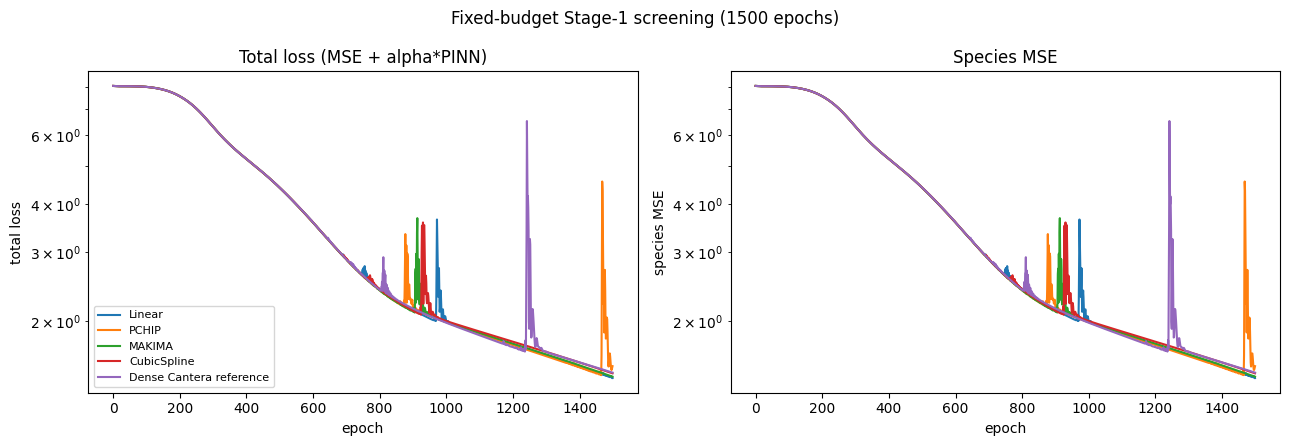

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name, _ in providers:
    ax[0].plot(results[name]["total"], label=name)
    ax[1].plot(results[name]["mse"], label=name)
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("total loss")
ax[0].set_title("Total loss (MSE + alpha*PINN)"); ax[0].legend(fontsize=8)
ax[1].set_yscale("log"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("species MSE")
ax[1].set_title("Species MSE")
plt.suptitle(f"Fixed-budget Stage-1 screening ({EPOCHS} epochs)")
plt.tight_layout(); plt.show()

### 10.10 Dense Cantera reference generation time (separate)

In [22]:
def gen_all_dense():
    # Full detailed-chemistry temperature trajectory for every training condition.
    return [ct_integrate(genh.MECH, genh.FUEL, genh.OXIDIZER, float(train_ics[b, 0]),
                         float(train_ics[b, 1]), t_dense, pressure, keep)[:, -1] for b in range(B)]

t0 = time.perf_counter(); _ = gen_all_dense(); dense_gen = time.perf_counter() - t0
print("Dense Cantera reference generation:")
print(f"total = {dense_gen * 1e3:.1f} ms")
print(f"per trajectory = {dense_gen / B * 1e3:.2f} ms")

Dense Cantera reference generation:
total = 359.6 ms
per trajectory = 10.27 ms


### 10.12 Held-out Stage-1 evaluation

The withheld condition (1150 K, phi=1.3) is integrated in Stage 1 with each trained model. Stage 1 still
receives an externally supplied temperature, so this is not the autonomous Stage-2 prediction -- each model
uses its own provider built from the held-out trajectory's data (dense Cantera for condition E).

In [23]:
test = load_hydrogen("test")
Y0_test = test["species_TBm"][0]                 # (1, m)
t_test = test["t"]
tgt_test = species_norm.normalize(test["species_TBm"])
Tt = test["T_obs_TB1"][:, :, 0].numpy(); tt = t_test.numpy()
T0_ho, phi_ho = genh.TEST_IC                     # held-out (1150 K, phi=1.3)
dense_ho = ct_integrate(genh.MECH, genh.FUEL, genh.OXIDIZER, float(T0_ho), float(phi_ho),
                        t_dense, pressure, keep)[:, -1]   # dense reference for the held-out case

test_providers = {
    "Linear": ObservedTemperature(test["t"], test["T_obs_TB1"]),
    "PCHIP": BatchInterpTemperature([PchipInterpolator(tt, Tt[:, 0])], lo, hi),
    "MAKIMA": BatchInterpTemperature([Akima1DInterpolator(tt, Tt[:, 0], method="makima")], lo, hi),
    "CubicSpline": BatchInterpTemperature([CubicSpline(tt, Tt[:, 0])], lo, hi),
    "Dense Cantera reference": BatchInterpTemperature([LinRef(t_dense, dense_ho)], lo, hi),
}

def heldout_mse(model, temp):
    kd = KineticDynamics(model.kinetic, temp, input_normalizer=full_norm)
    with torch.no_grad():
        pred = integrate(kd, Y0_test, t_test, solver)
    return float(trajectory_mse(species_norm.normalize(pred), tgt_test))

for name, _ in providers:
    results[name]["heldout"] = heldout_mse(results[name]["model"], test_providers[name])
    print(f"{name:24s} held-out Stage-1 species MSE {results[name]['heldout']:.3e}")

Linear                   held-out Stage-1 species MSE 1.871e+00
PCHIP                    held-out Stage-1 species MSE 1.892e+00
MAKIMA                   held-out Stage-1 species MSE 1.885e+00
CubicSpline              held-out Stage-1 species MSE 1.911e+00
Dense Cantera reference  held-out Stage-1 species MSE 1.910e+00


Held-out Stage-1 Eq. 18 species MSE term is used

### 10.13 Main result table

In [24]:
tbl = pd.DataFrame([{
    "Provider": name,
    "Final total loss": f"{results[name]['total'][-1]:.3e}",
    "Final species MSE": f"{results[name]['mse'][-1]:.3e}",
    "Final weighted PINN": f"{results[name]['pinn'][-1]:.3e}",
    "Held-out Stage-1 species MSE": f"{results[name]['heldout']:.3e}",
    "Training time [s]": round(results[name]["time"], 1),
    "RHS calls": results[name]["rhs"],
} for name, _ in providers])
tbl

,Provider,Final total loss,Final species MSE,Final weighted PINN,Held-out Stage-1 species MSE,Training time [s],RHS calls
0,Linear,1.427e+00,1.427e+00,3.306e-05,1.871e+00,241.2,512760
1,PCHIP,1.531e+00,1.531e+00,3.117e-05,1.892e+00,235.7,426420
2,MAKIMA,1.439e+00,1.439e+00,3.024e-05,1.885e+00,237.2,426750
3,CubicSpline,1.468e+00,1.468e+00,3.005e-05,1.911e+00,214.2,373884
4,Dense Cantera reference,1.474e+00,1.474e+00,3.079e-05,1.910e+00,260.1,441108


> Linear, PCHIP, MAKIMA, and CubicSpline use the same sparse temperature observations. Dense Cantera
reference uses additional high-resolution temperature information and is therefore shown as a separate
reference condition rather than a directly equivalent interpolation method.
Training uses $L_{MSE}​+10^{−4} L_{PINN}$​. The held-out diagnostic reports only the Eq. 18 species MSE term; the PINN term is not included in the reported held-out value

### 10.14 Per-species held-out error (screening models)

Held-out Stage-1 error per species, in normalized space (the same space as the training loss), for the five
screening models.

In [25]:
species_names = [str(s) for s in hy["species"]]   # species order from the dataset metadata

def heldout_species_mse(model, temp):
    # Per-species normalized-space MSE over the held-out trajectory.
    kd = KineticDynamics(model.kinetic, temp, input_normalizer=full_norm)
    with torch.no_grad():
        pred = integrate(kd, Y0_test, t_test, solver)
    e = species_norm.normalize(pred) - tgt_test        # (T, 1, m), normalized space
    return (e ** 2).mean(dim=(0, 1)).numpy()           # (m,)

screen_species = pd.DataFrame(
    {name: heldout_species_mse(results[name]["model"], test_providers[name]) for name, _ in providers},
    index=species_names)
screen_species.index.name = "Species"
screen_species

,Linear,PCHIP,MAKIMA,CubicSpline,Dense Cantera reference
Species,,,,,
H2,0.023981,0.022782,0.025683,0.025805,0.024918
H,0.018658,0.018575,0.018448,0.019069,0.018964
O,0.019492,0.019988,0.019865,0.020674,0.020992
O2,0.108637,0.112109,0.108244,0.108869,0.108529
OH,0.051312,0.043219,0.053035,0.055022,0.057043
H2O,0.103365,0.108996,0.103274,0.103581,0.102787
HO2,0.009665,0.008921,0.009273,0.009294,0.008395
H2O2,0.001604,0.005819,0.001466,0.001499,0.002035
N2,0.000097,0.000083,0.000038,0.000085,0.000090


## 11. Longer Stage-1 comparison

The three most relevant providers -- **Linear** (current implementation), **PCHIP** (the sparse interpolation method with the lowest worst-case error in the 35-condition audit), and the **Dense Cantera reference** -- are retrained at the normal Stage-1
budget (`train_hydrogen.py` default: 10000 epochs). MAKIMA and CubicSpline are not repeated; the screening
already covers them. Everything except the temperature provider is held fixed, and all three start from the
same initial weights.

At 10000 epochs this is a multi-hour run for three providers. Set `NB_LONG_EPOCHS` (and `NB_SCREEN_EPOCHS`
for Section 10) to a smaller value for a quick check; both default to the full budget.

### 11.1 Long runs 
Current reproduction Stage-1 budget (10,000 epochs)

In [26]:
LONG_EPOCHS = int(os.environ.get("NB_LONG_EPOCHS", "10000"))   # normal Stage-1 budget (train_hydrogen.py)
long_providers = [("Linear", prov_linear), ("PCHIP", prov_pchip), ("Dense Cantera reference", prov_dense)]

long_results = {}
for name, temp in long_providers:
    # Use the same initial weights so temperature handling is the only intended difference.
    model = ChemKAN(species_dim=m, hidden_dim=3, num_basis=5, n_mu=3, use_base_act=False)
    model.load_state_dict(copy.deepcopy(initial_state))
    init_diff = max((model.state_dict()[k] - initial_state[k]).abs().max().item() for k in initial_state)

    kd = KineticDynamics(model.kinetic, temp, input_normalizer=full_norm)
    # Different T(t) curves can change adaptive solver step acceptance, so RHS counts differ.
    n_rhs = [0]
    h = kd.register_forward_pre_hook(lambda mod, args: n_rhs.__setitem__(0, n_rhs[0] + 1))

    opt = torch.optim.Adam(kd.kinetic.parameters(), lr=2e-3)
    total_hist, mse_hist, pinn_hist = [], [], []
    t0 = time.perf_counter()
    for _ in range(LONG_EPOCHS):
        opt.zero_grad()
        pred = integrate(kd, Y0_train, t_train, solver)
        mse, pinn = stage1_terms(pred)
        loss = mse + ALPHA_PINN * pinn
        loss.backward(); opt.step()
        total_hist.append(loss.detach().item())
        mse_hist.append(mse.detach().item())
        pinn_hist.append((ALPHA_PINN * pinn).detach().item())   # weighted contribution
    train_time = time.perf_counter() - t0
    h.remove()

    long_results[name] = {"model": model, "total": total_hist, "mse": mse_hist, "pinn": pinn_hist,
                          "time": train_time, "rhs": n_rhs[0], "init_diff": init_diff}
    print(f"{name:24s} total {total_hist[-1]:.3e} | mse {mse_hist[-1]:.3e} | "
          f"wPINN {pinn_hist[-1]:.3e} | {train_time:6.1f} s | {n_rhs[0]} RHS | init diff {init_diff:.1e}")

print()
print(f"Max initial parameter difference (long runs): {max(r['init_diff'] for r in long_results.values()):.1f}")
print(f"Long-run epochs: {LONG_EPOCHS}")

Linear                   total 3.204e-01 | mse 3.204e-01 | wPINN 1.304e-05 | 4082.2 s | 8600576 RHS | init diff 0.0e+00
PCHIP                    total 5.345e-01 | mse 5.344e-01 | wPINN 5.452e-05 | 3345.3 s | 5760686 RHS | init diff 0.0e+00
Dense Cantera reference  total 3.357e-01 | mse 3.357e-01 | wPINN 1.354e-05 | 3600.5 s | 5829926 RHS | init diff 0.0e+00

Max initial parameter difference (long runs): 0.0
Long-run epochs: 10000


### 11.2 Long-run training loss

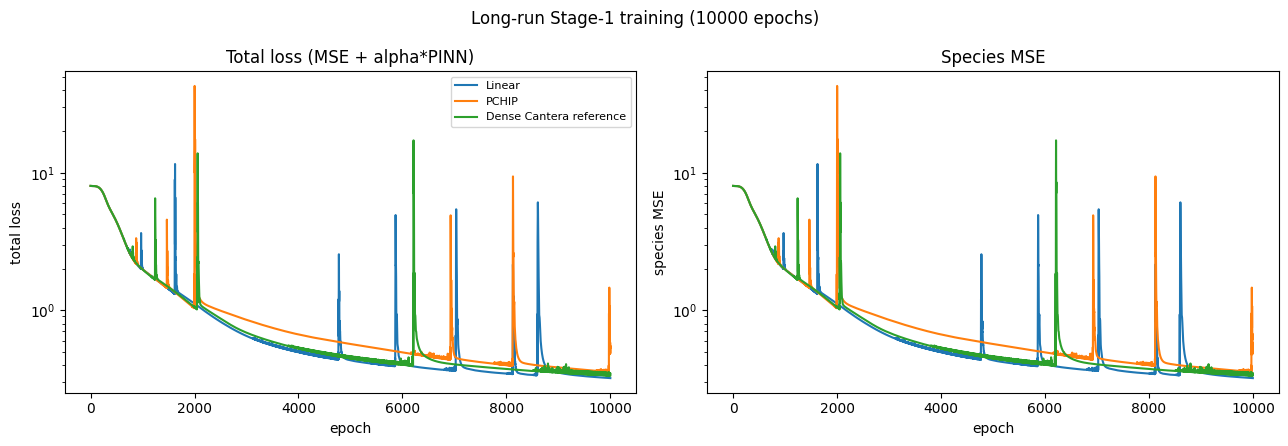

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name, _ in long_providers:
    ax[0].plot(long_results[name]["total"], label=name)
    ax[1].plot(long_results[name]["mse"], label=name)
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("total loss")
ax[0].set_title("Total loss (MSE + alpha*PINN)"); ax[0].legend(fontsize=8)
ax[1].set_yscale("log"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("species MSE")
ax[1].set_title("Species MSE")
plt.suptitle(f"Long-run Stage-1 training ({LONG_EPOCHS} epochs)")
plt.tight_layout(); plt.show()

### 11.3 Long-run held-out evaluation and result table

In [28]:
for name, _ in long_providers:
    long_results[name]["heldout"] = heldout_mse(long_results[name]["model"], test_providers[name])

long_tbl = pd.DataFrame([{
    "Provider": name,
    "Epochs": LONG_EPOCHS,
    "Final total loss": f"{long_results[name]['total'][-1]:.3e}",
    "Final species MSE": f"{long_results[name]['mse'][-1]:.3e}",
    "Final weighted PINN": f"{long_results[name]['pinn'][-1]:.3e}",
    "Held-out Stage-1 species MSE": f"{long_results[name]['heldout']:.3e}",
    "Training time [s]": round(long_results[name]["time"], 1),
    "RHS calls": long_results[name]["rhs"],
} for name, _ in long_providers])
long_tbl

,Provider,Epochs,Final total loss,Final species MSE,Final weighted PINN,Held-out Stage-1 species MSE,Training time [s],RHS calls
0,Linear,10000,3.204e-01,3.204e-01,1.304e-05,2.537e-01,4082.2,8600576
1,PCHIP,10000,5.345e-01,5.344e-01,5.452e-05,3.721e-01,3345.3,5760686
2,Dense Cantera reference,10000,3.357e-01,3.357e-01,1.354e-05,2.635e-01,3600.5,5829926


> Linear and PCHIP use only the original sparse temperature observations. The Dense Cantera reference
condition uses additional high-resolution temperature information and is included as a reference condition
rather than a directly equivalent interpolation method.
>
> These are Stage-1 results with externally supplied temperature, not final Stage-2 ChemKAN predictions.
Different temperature providers change the ODE right-hand side and can therefore change the adaptive solver's
internal step sequence; fewer RHS evaluations do not necessarily imply better model quality.

### 11.4 Long-run per-species held-out error

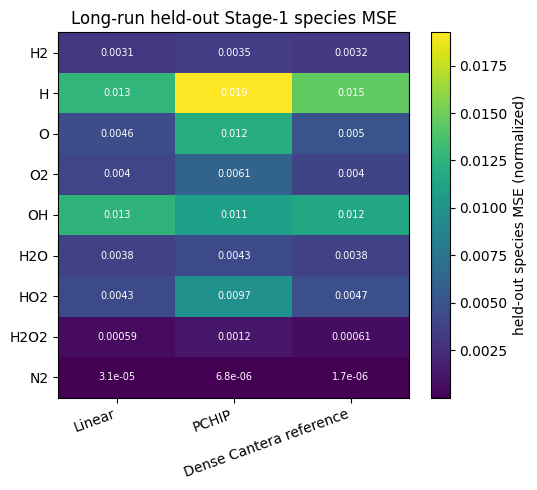

,Linear,PCHIP,Dense Cantera reference
Species,,,
H2,0.003096,0.003525,0.003212
H,0.012706,0.019255,0.014518
O,0.004568,0.012007,0.005031
O2,0.004034,0.006094,0.003970
OH,0.012554,0.010854,0.011578
H2O,0.003788,0.004342,0.003777
HO2,0.004298,0.009706,0.004734
H2O2,0.000586,0.001195,0.000605
N2,0.000031,0.000007,0.000002


In [29]:
long_species = pd.DataFrame(
    {name: heldout_species_mse(long_results[name]["model"], test_providers[name]) for name, _ in long_providers},
    index=species_names)
long_species.index.name = "Species"

# Per-species errors help reveal whether interpolation differences
# are concentrated in particular reaction intermediates.
fig, axh = plt.subplots(figsize=(5.5, 5))
im = axh.imshow(long_species.values, aspect="auto", cmap="viridis")
axh.set_xticks(range(long_species.shape[1])); axh.set_xticklabels(long_species.columns, rotation=20, ha="right")
axh.set_yticks(range(len(species_names))); axh.set_yticklabels(species_names)
for i in range(long_species.shape[0]):
    for j in range(long_species.shape[1]):
        axh.text(j, i, f"{long_species.values[i, j]:.2g}", ha="center", va="center", color="w", fontsize=7)
plt.colorbar(im, label="held-out species MSE (normalized)")
plt.title("Long-run held-out Stage-1 species MSE"); plt.tight_layout(); plt.show()
long_species

### 11.5 Long-run held-out species trajectories

Held-out condition (1150 K, phi=1.3): observed vs Linear, PCHIP and the Dense Cantera reference. These are
**Stage-1 species predictions with externally supplied temperature**, not autonomous Stage-2 predictions.

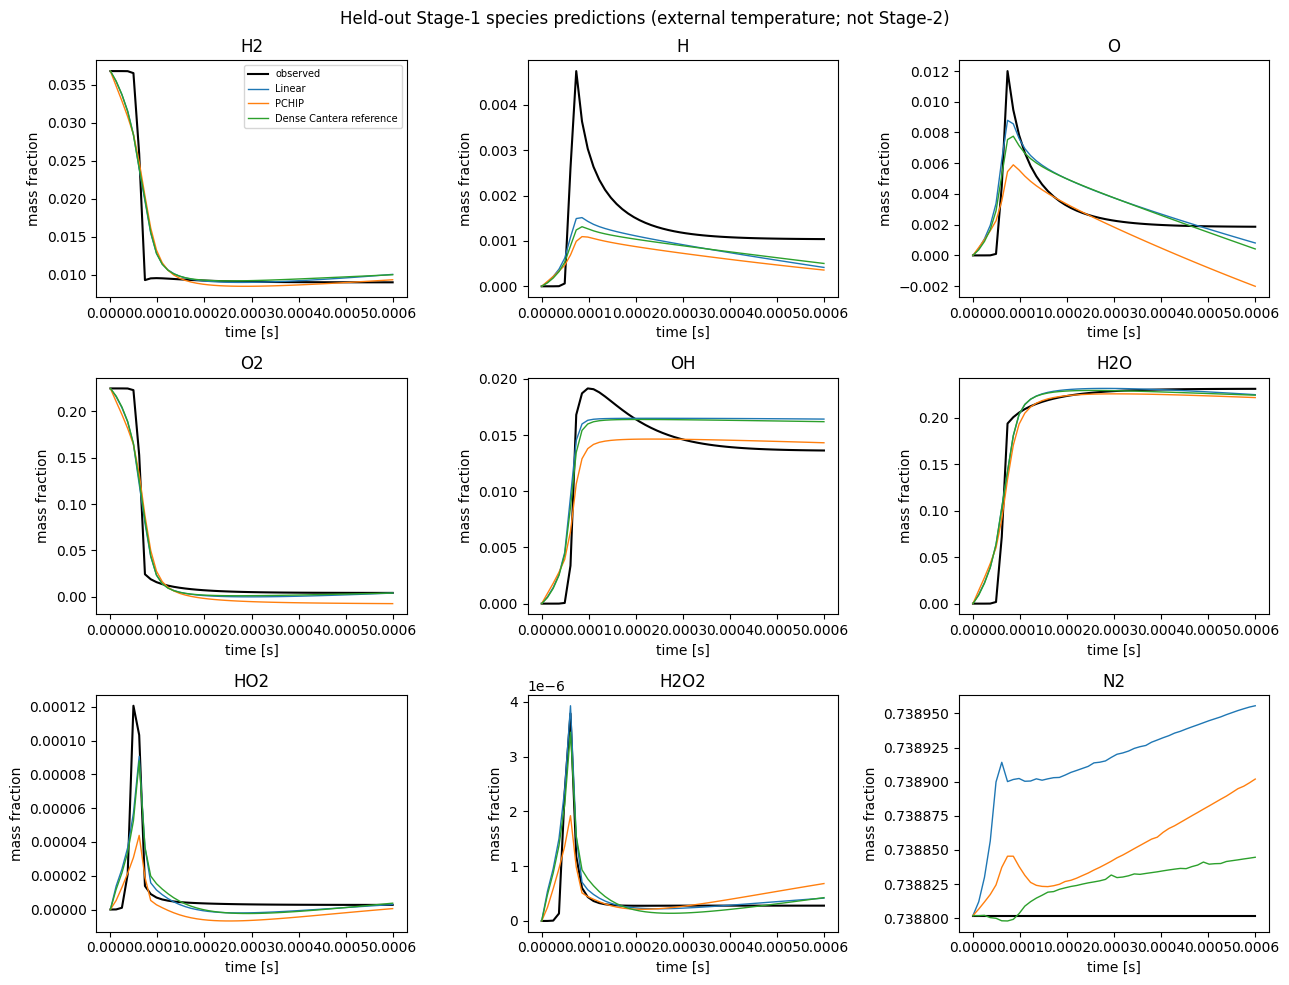

In [30]:
def heldout_pred(model, temp):
    # Stage 1 predicts species only; temperature is externally supplied.
    kd = KineticDynamics(model.kinetic, temp, input_normalizer=full_norm)
    with torch.no_grad():
        return integrate(kd, Y0_test, t_test, solver)[:, 0, :].numpy()   # (T, m) physical mass fractions

obs = test["species_TBm"][:, 0, :].numpy()
preds = {name: heldout_pred(long_results[name]["model"], test_providers[name]) for name, _ in long_providers}

fig, ax = plt.subplots(3, 3, figsize=(13, 10))
for i, sp in enumerate(species_names):
    a = ax[i // 3, i % 3]
    a.plot(tt, obs[:, i], "k-", lw=1.5, label="observed")
    a.plot(tt, preds["Linear"][:, i], lw=1.0, label="Linear")
    a.plot(tt, preds["PCHIP"][:, i], lw=1.0, label="PCHIP")
    a.plot(tt, preds["Dense Cantera reference"][:, i], lw=1.0, label="Dense Cantera reference")
    a.set_title(sp); a.set_xlabel("time [s]"); a.set_ylabel("mass fraction")
ax[0, 0].legend(fontsize=7)
plt.suptitle("Held-out Stage-1 species predictions (external temperature; not Stage-2)")
plt.tight_layout(); plt.show()

## Checked

- Biodiesel temperature path
- Hydrogen temperature range
- Linear interpolation vs dense Cantera
- Stage-1 temperature call path
- ODE internal evaluation times
- Linear interpolation error across hydrogen conditions
- Stage-2 temperature path
- Alternatives to linear interpolation
- Linear / PCHIP / MAKIMA / cubic-spline comparison
- Exact-RHS Cantera comparison
- End-to-end Stage-1 timing per temperature provider
- Fixed-budget (1500-epoch) screening across five providers
- Per-species held-out error (screening)
- Dense Cantera reference generation time
- Longer Stage-1 comparison (Linear / PCHIP / Dense Cantera reference) at the normal budget
- Long-run result table, per-species heatmap, and held-out species trajectories